## <center> Will this Customer Purchase Your Product? <center>

In [151]:
# Import necessary libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

In [152]:
# Import the dataset
shopping_data = pd.read_csv("C:/Users/uhoan/OneDrive/Desktop/Real-World-Projects/Python/datasets/online_shopping_session_data.csv")
shopping_data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


In [153]:
# List the unique values in the 'CustomerType' column
shopping_data["CustomerType"].unique()

array(['Returning_Customer', 'New_Customer', nan], dtype=object)

In [154]:
# Filter out missing values in the 'CustomerType' column
shopping_data = shopping_data[shopping_data["CustomerType"].notnull()]
shopping_data["CustomerType"].unique()

array(['Returning_Customer', 'New_Customer'], dtype=object)

In [155]:
# Filter by November and December
shopping_data = shopping_data[(shopping_data["Month"] == "Nov") | (shopping_data["Month"] == "Dec")]
shopping_data["Month"].unique()

array(['Nov', 'Dec'], dtype=object)

In [156]:
# Find the percentage of customers that made/did not make a purchase by customer type
purchase_percentage = shopping_data.groupby("CustomerType")["Purchase"].value_counts(normalize=True) * 100
purchase_percentage

CustomerType        Purchase
New_Customer        0.0         72.664835
                    1.0         27.335165
Returning_Customer  0.0         80.440623
                    1.0         19.559377
Name: proportion, dtype: float64

In [157]:
# Store the purchase rates by customer type
purchase_rates = {"Returning_Customer": 0.273, "New_Customer": 0.196}
purchase_rates

{'Returning_Customer': 0.273, 'New_Customer': 0.196}

In [158]:
# Filter for returning customers
shopping_data_returning = shopping_data[shopping_data["CustomerType"] == "Returning_Customer"]
shopping_data_returning["CustomerType"].unique()

array(['Returning_Customer'], dtype=object)

In [159]:
# Check for missing values in the shopping_data_returning dataset
shopping_data_returning.isnull().sum()

SessionID                  0
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Weekend                    0
Month                      0
CustomerType               0
Purchase                   0
dtype: int64

In [160]:
# Subset for Adminstrativve_Duration, Informational_Duration, and ProductRelated_Duration
shopping_data_returning_subset = shopping_data_returning[["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]]
shopping_data_returning_subset.head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration
5464,89.600000,0.0,1721.906667
5467,204.200000,0.0,652.376667
5479,0.000000,0.0,710.066667
5494,0.000000,0.0,968.692424
5497,1013.056909,102.8,2697.022104


In [161]:
# Correlation between the pages
correlations = shopping_data_returning_subset.corr()
correlations

,Administrative_Duration,Informational_Duration,ProductRelated_Duration
Administrative_Duration,1.000000,0.258108,0.416893
Informational_Duration,0.258108,1.000000,0.366551
ProductRelated_Duration,0.416893,0.366551,1.000000


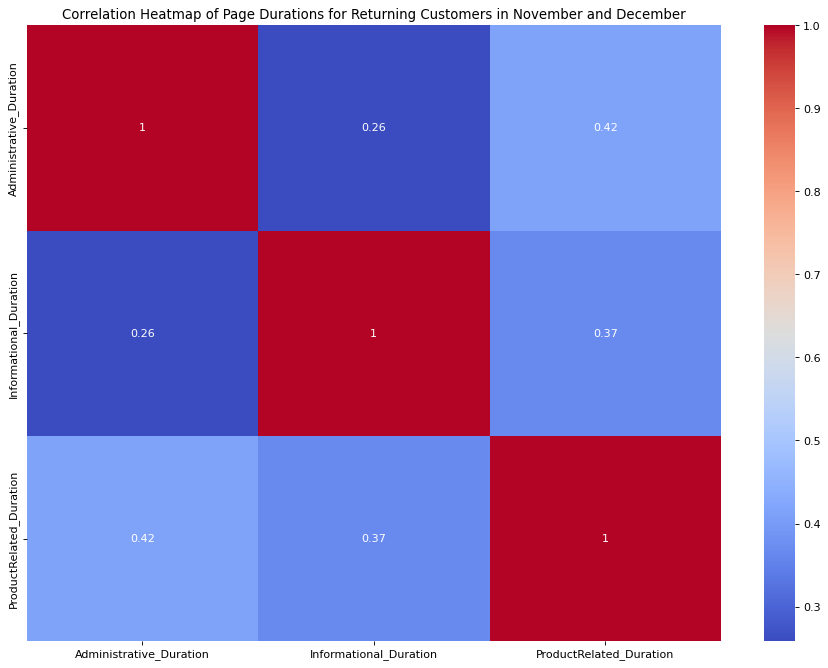

In [162]:
# Create a heatmap for the correlations
plt.figure(figsize=(14,10), dpi=80, )
sns.heatmap(correlations, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Page Durations for Returning Customers in November and December", fontsize=12)
plt.show()

In [163]:
# Strongest correlation
top_correlation = {"pair": ("Adminstrative_Duration", "ProductRelated_Duration"), "correlation": 0.417}

In [164]:
# Likelihood of at least 100 sales out of 500 for returning customers
prob_at_least_100_sales = 1 - stats.binom.cdf(100, 500, 0.196)